# Nama: Rayendra Aldo Putra
# NIM: 4222301064
# Kelas: Robotika Pagi C

In [21]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [22]:
df = pd.read_csv('WineQT.csv')
# Drop kolom Id karena bukan fitur
df = df.drop(columns=['Id'])
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## EDA

Text(0.5, 1.0, 'Sebaran Nilai alcohol vs volatile acidity')

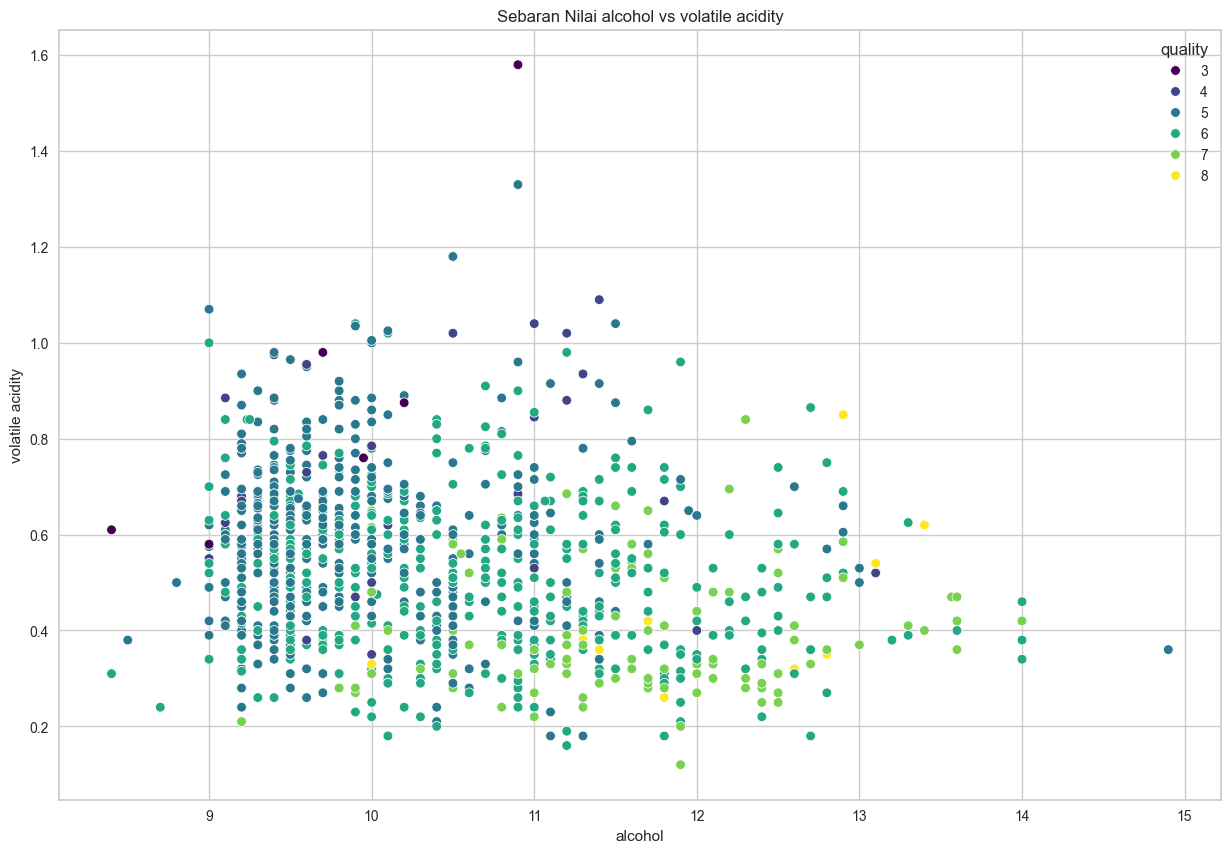

In [23]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='volatile acidity', hue='quality', palette='viridis')
plt.title('Sebaran Nilai alcohol vs volatile acidity')

In [24]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


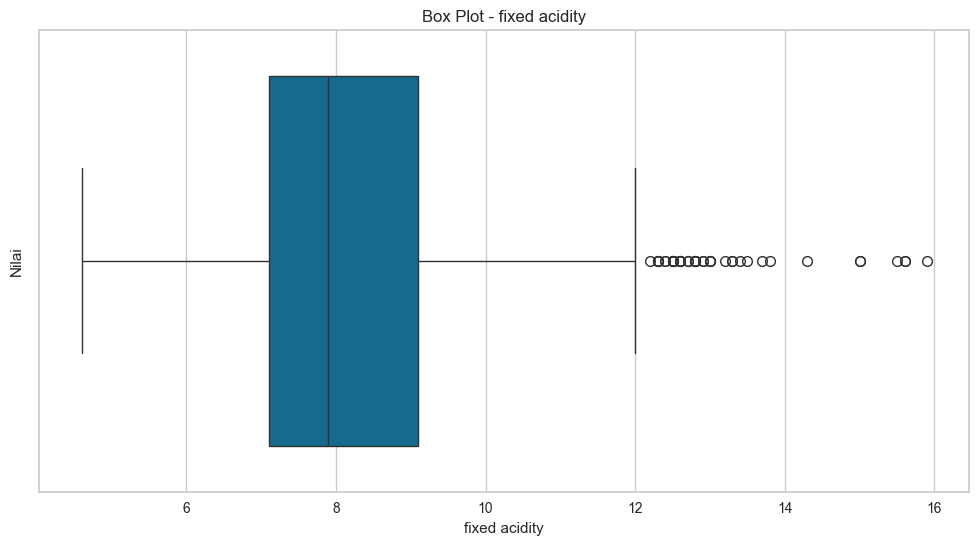

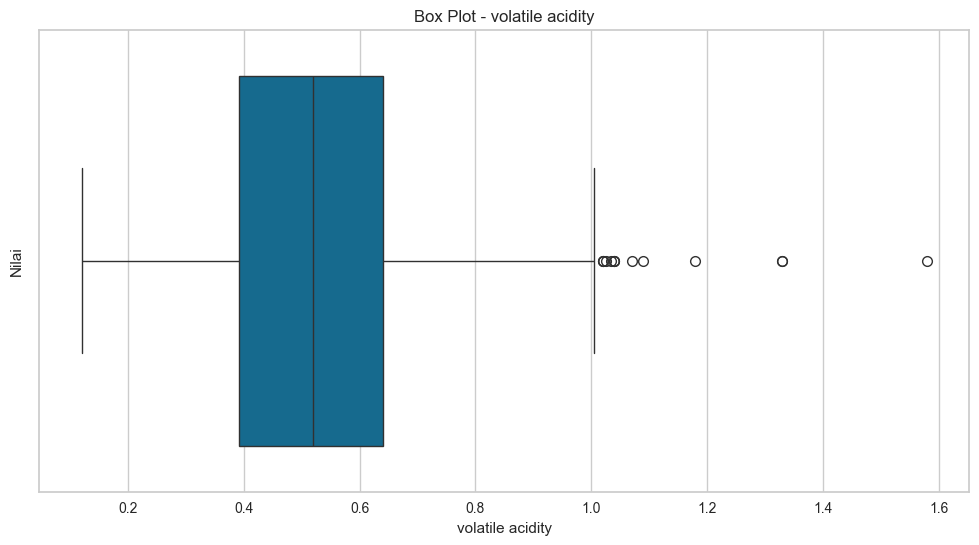

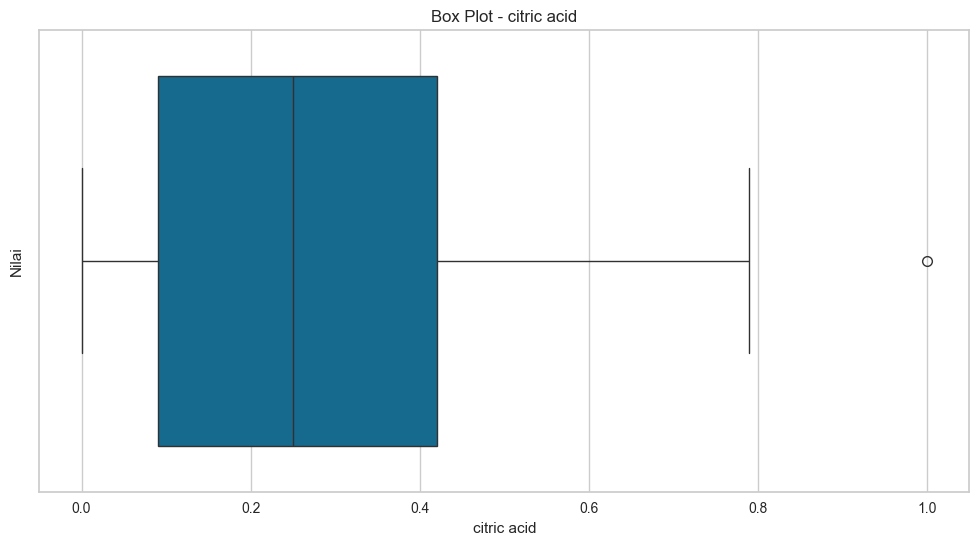

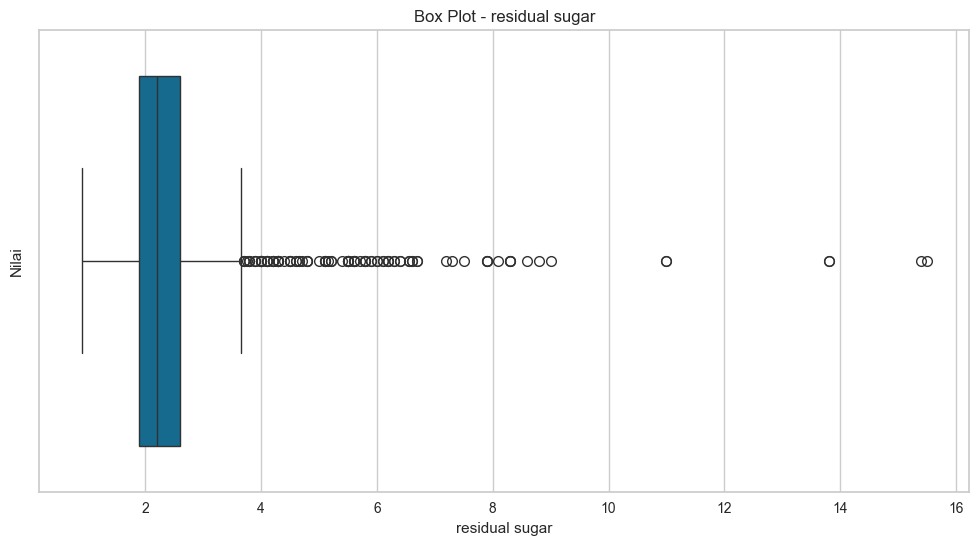

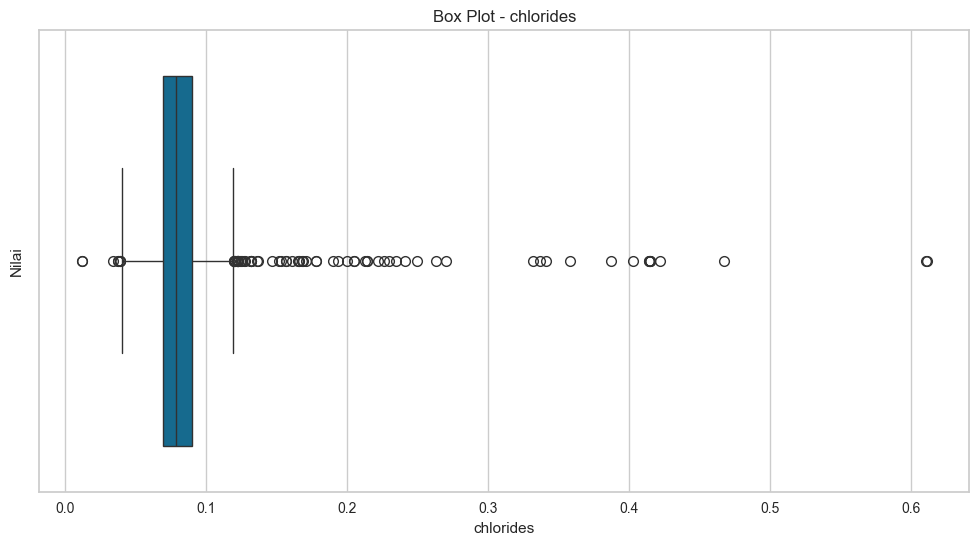

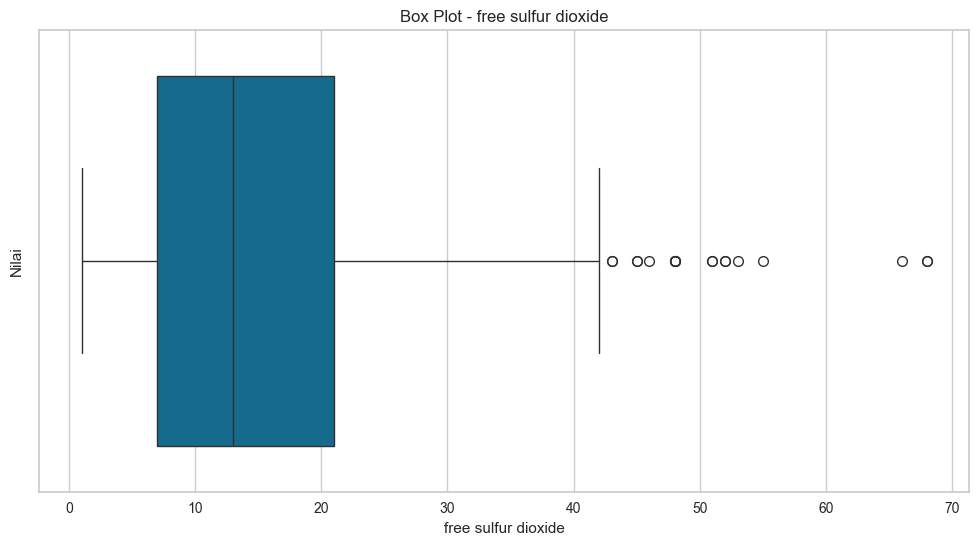

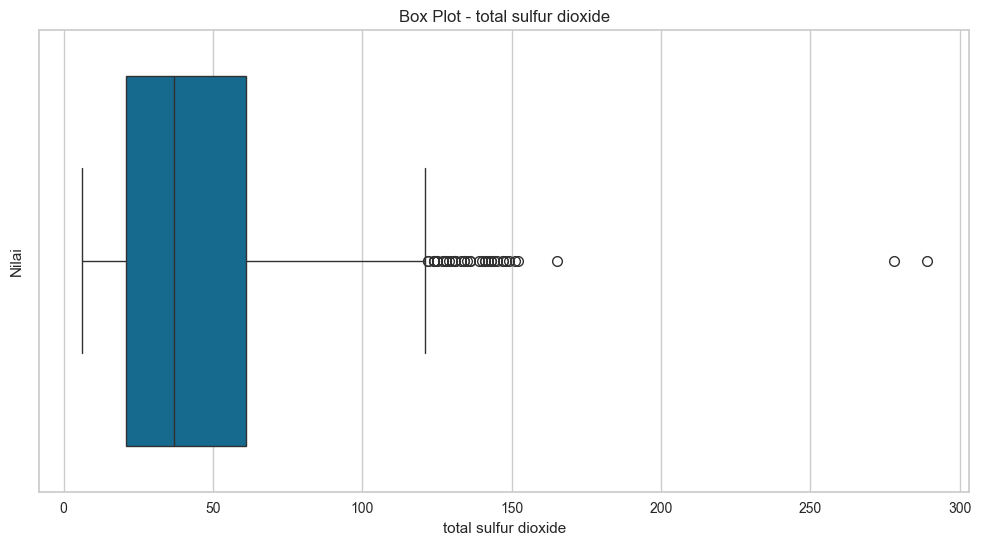

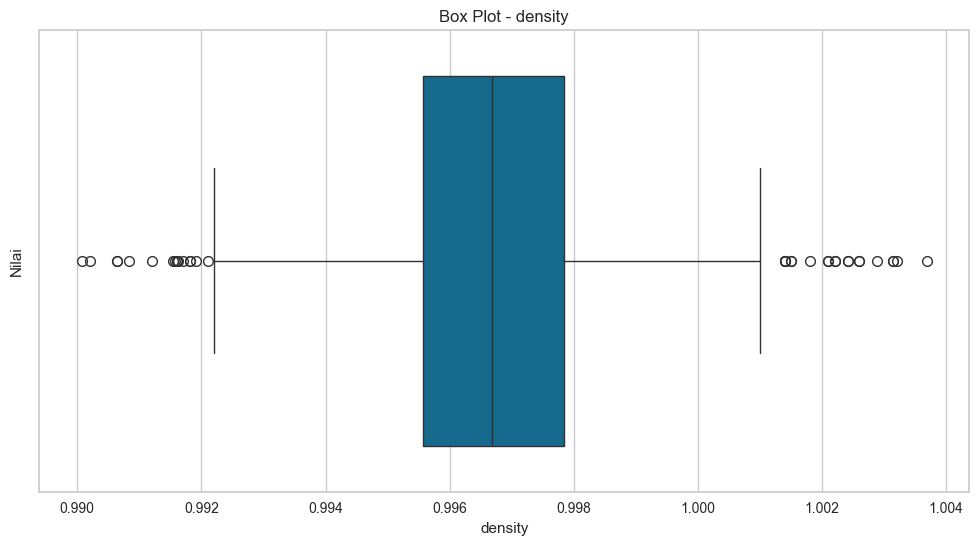

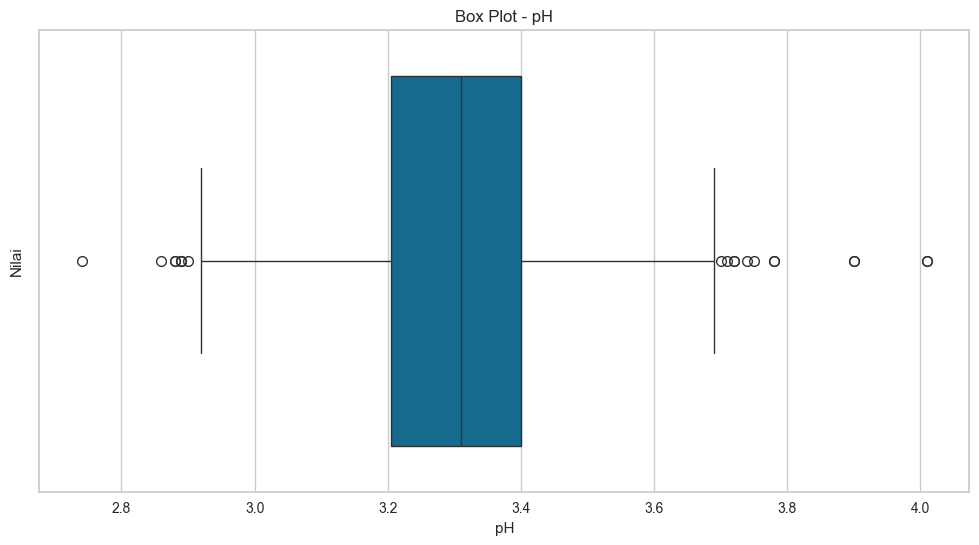

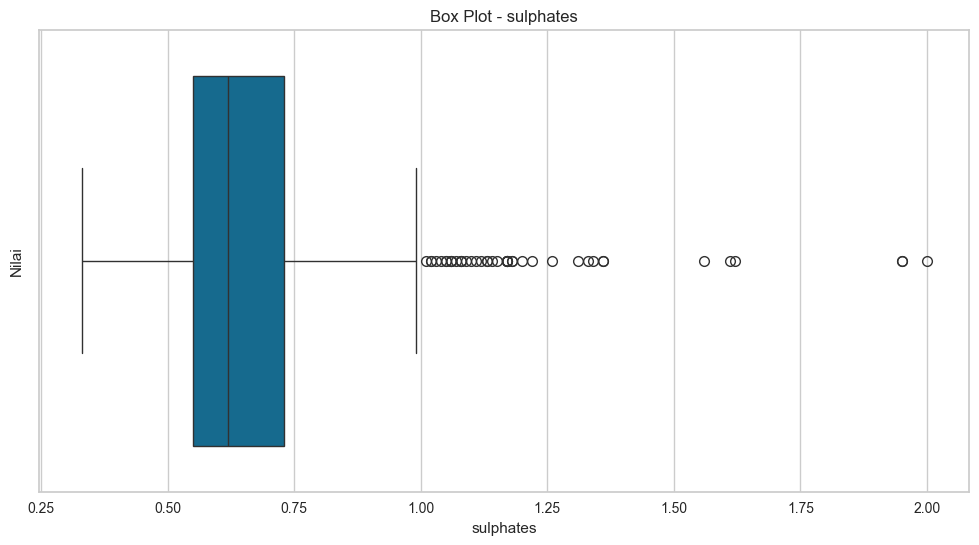

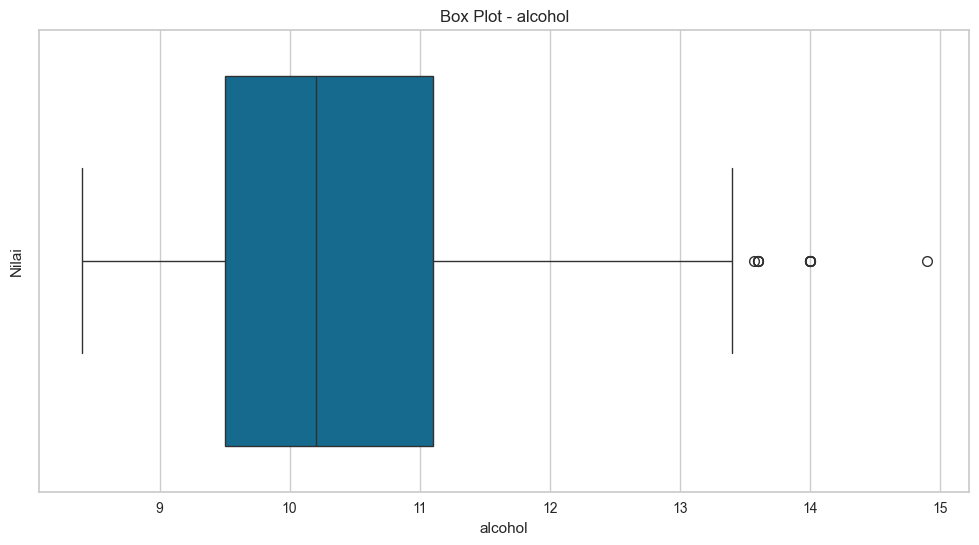

In [25]:
# Looping untuk semua kolom fitur
columns = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
           'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
           'density', 'pH', 'sulphates', 'alcohol']

for col in columns:
    # Box plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot - {col}')
    plt.xlabel(col)
    plt.ylabel('Nilai')
    plt.show()

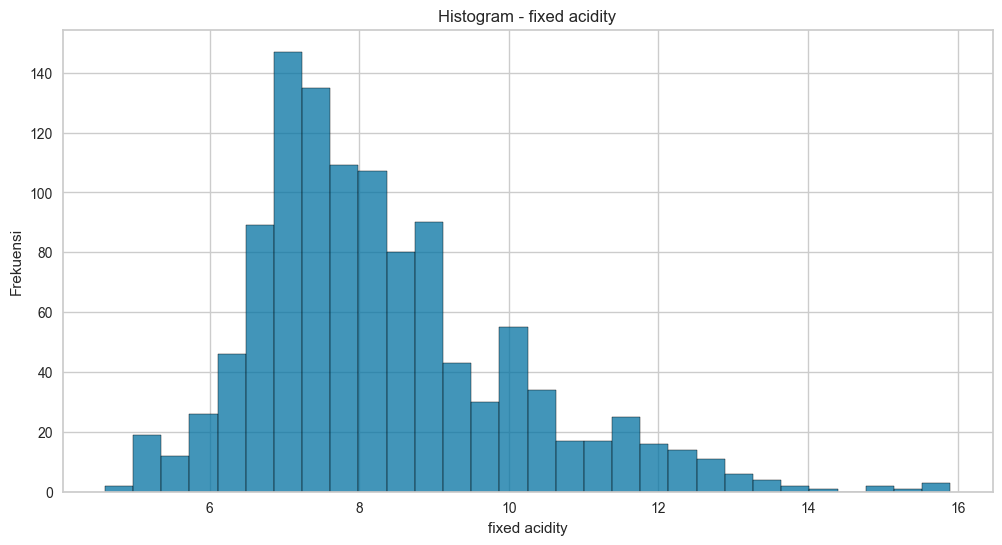

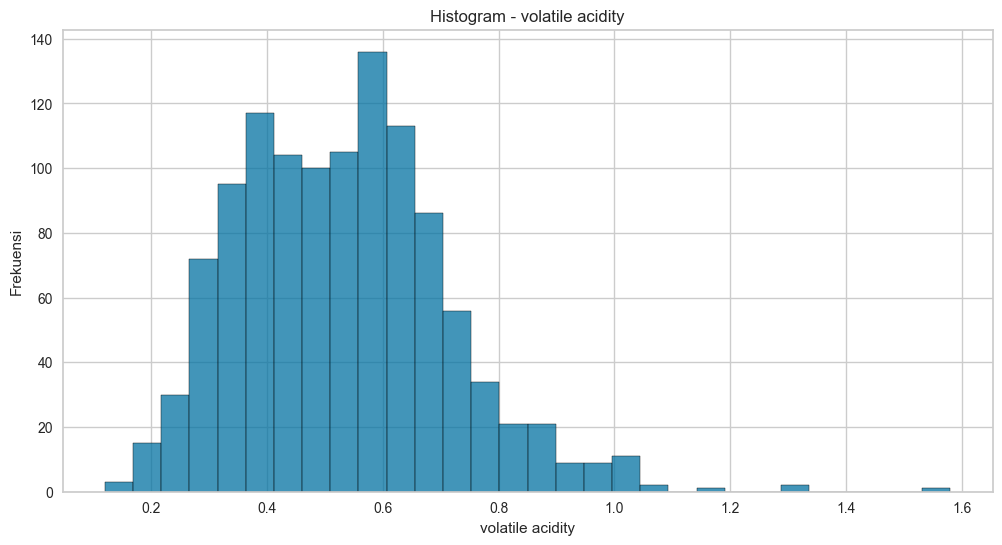

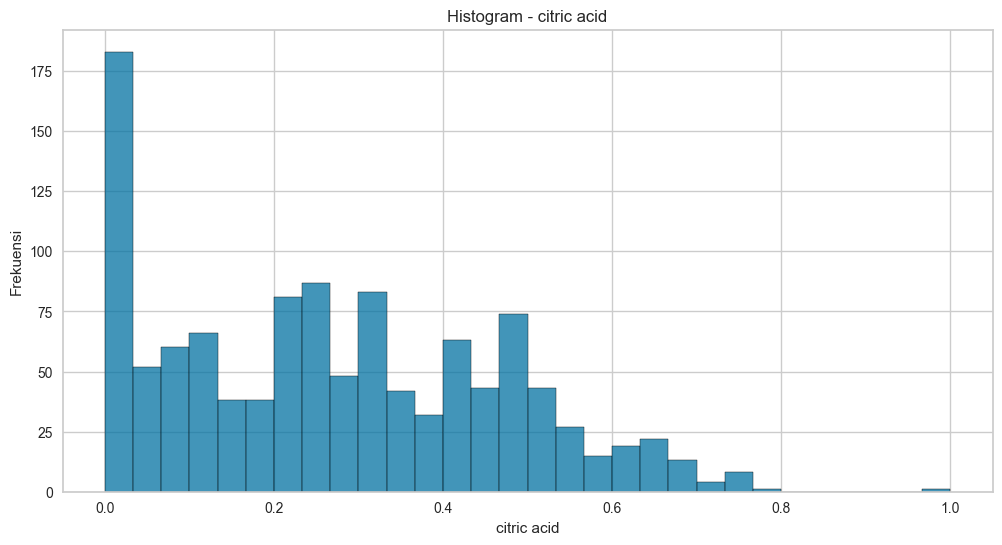

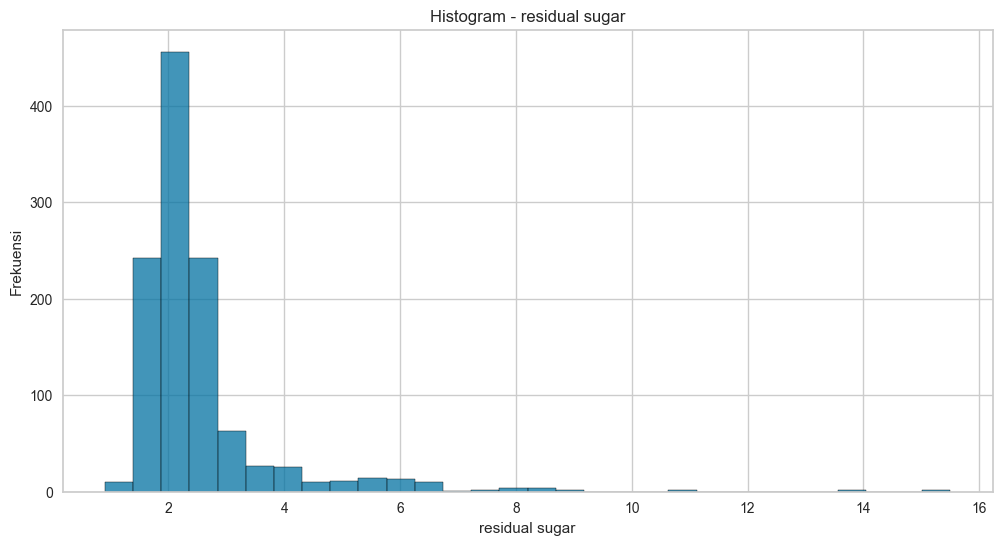

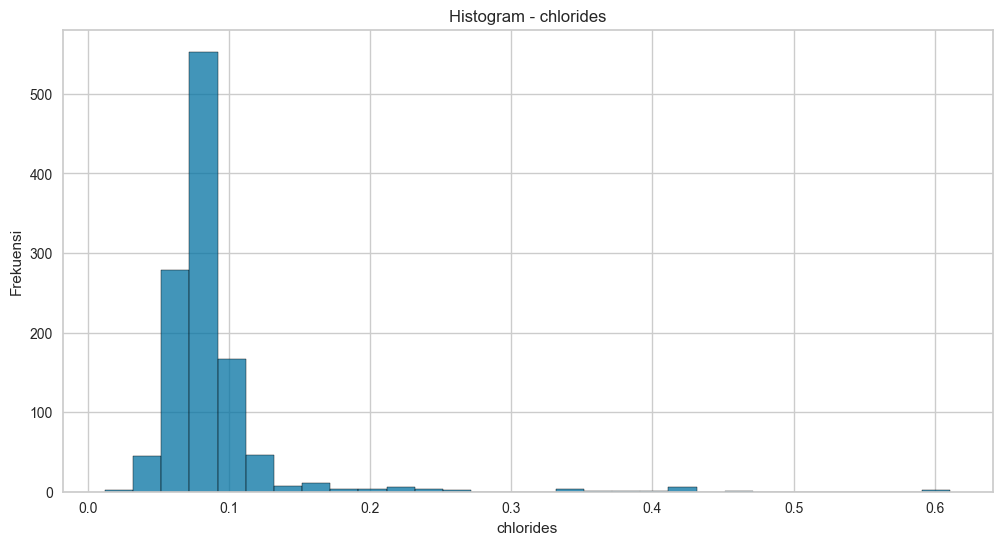

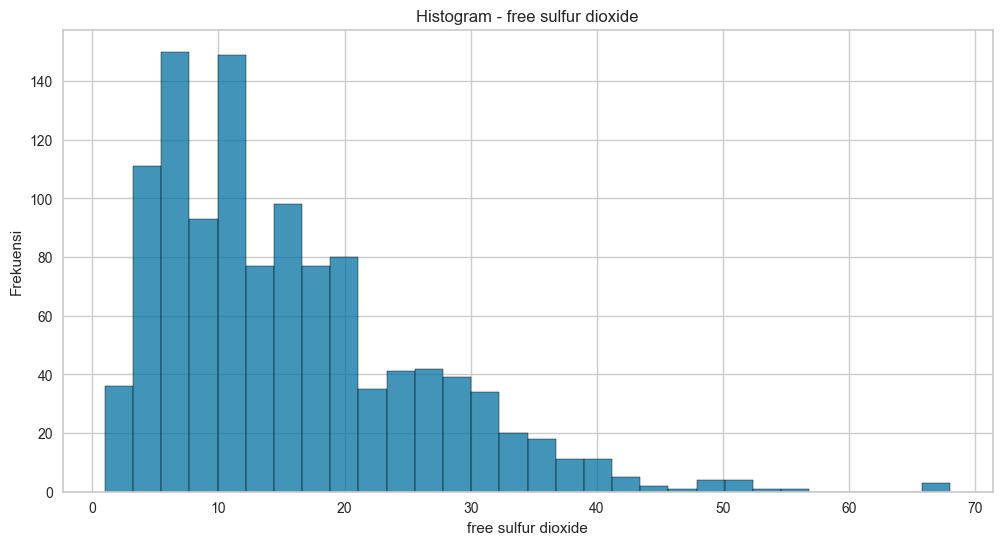

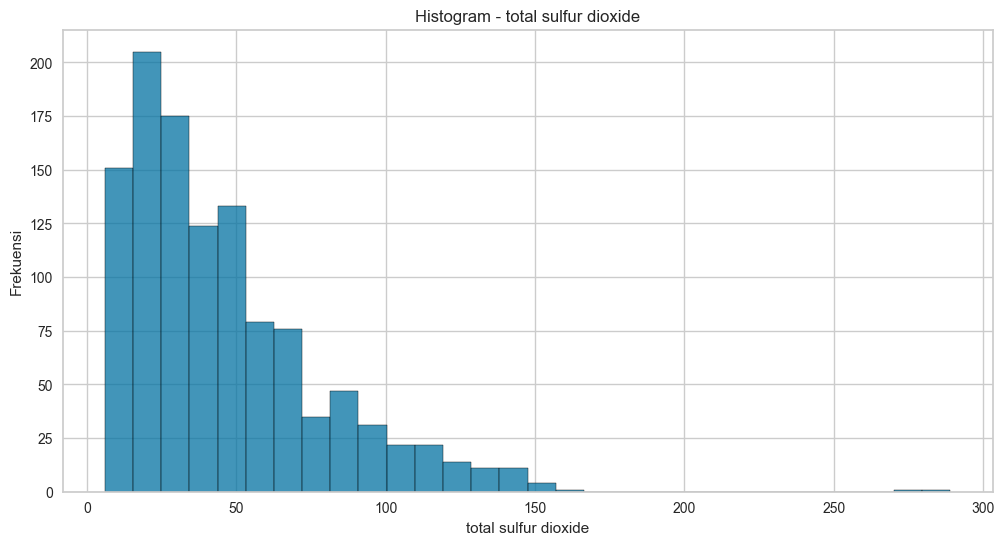

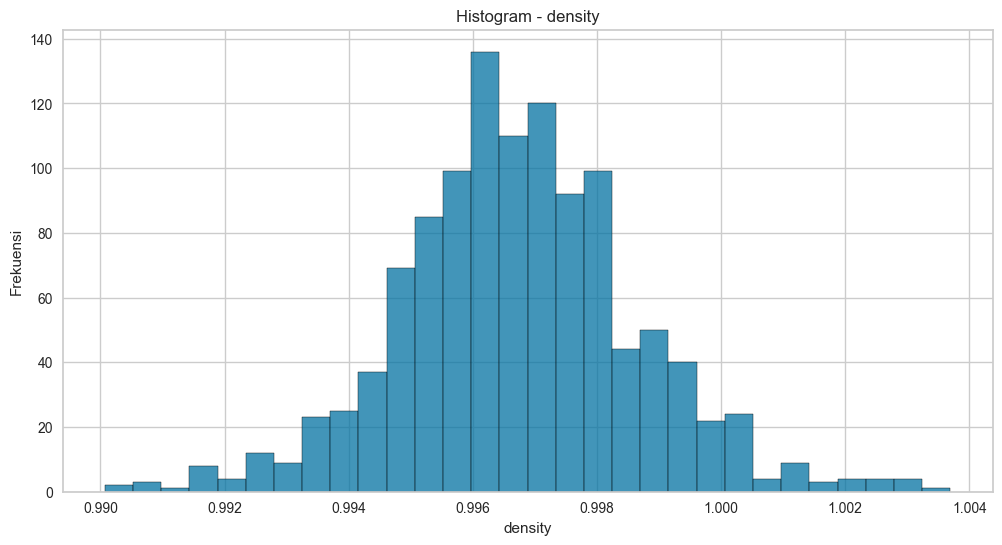

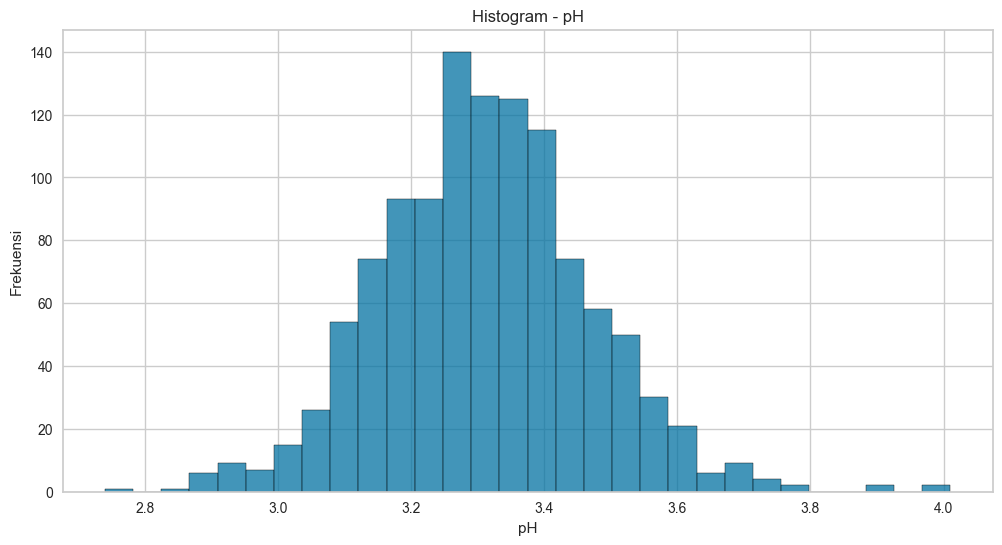

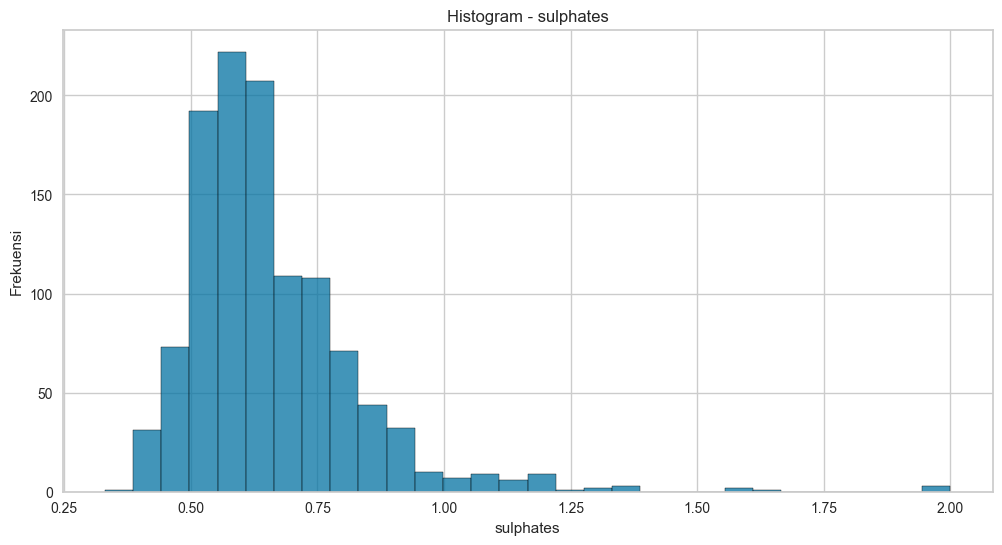

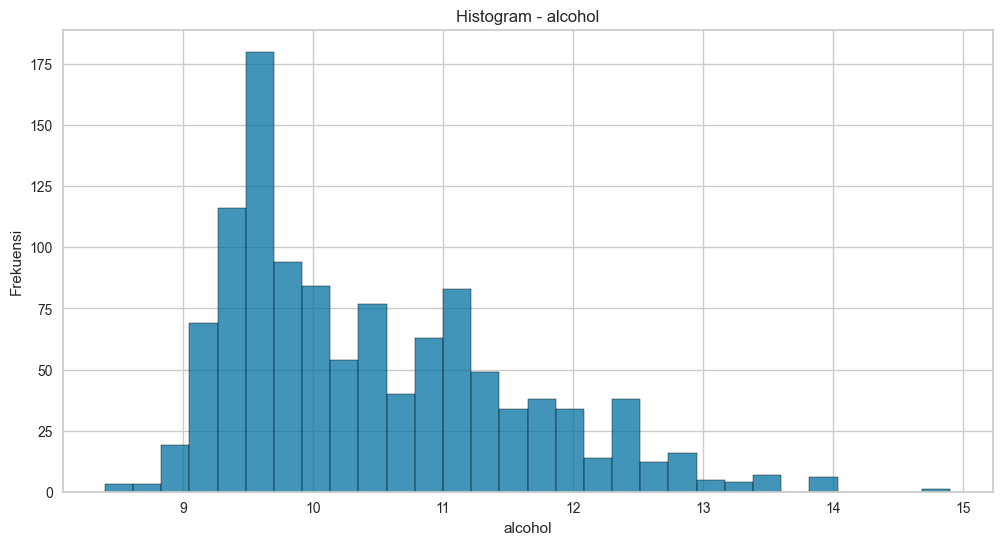

In [26]:
for col in columns:
    # Histogram
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Histogram - {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)
3. Feature Scalling

In [27]:
# Drop Duplicates

print(f"Dataframe dimension before duplication drop {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 1143
Dataframe dimension after duplication drop 1018


dari hasil running program diatas, dapat dilihat jumlah data sebelum dan sesudah drop duplikat

In [28]:
fitur_columns = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
                 'density', 'pH', 'sulphates', 'alcohol']
X = df[fitur_columns].values
y = df['quality'].values #anotator label

In [29]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data = X_std, columns = fitur_columns )
df_scalling.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1.018000e+03,1.018000e+03,1.018000e+03,1.018000e+03,1.018000e+03,1.018000e+03,1.018000e+03,1.018000e+03,1.018000e+03,1.018000e+03,1.018000e+03
mean,-7.258983e-16,2.024139e-16,-2.791916e-17,-3.978481e-16,-1.395958e-16,-8.375749e-17,-1.116767e-16,-3.685330e-15,-1.703069e-15,1.095827e-15,-5.583833e-17
std,1.000492e+00,1.000492e+00,1.000492e+00,1.000492e+00,1.000492e+00,1.000492e+00,1.000492e+00,1.000492e+00,1.000492e+00,1.000492e+00,1.000492e+00
min,-2.119261e+00,-2.258834e+00,-1.370507e+00,-1.236041e+00,-1.550822e+00,-1.440179e+00,-1.218030e+00,-3.461076e+00,-3.624041e+00,-1.951619e+00,-1.875200e+00
25%,-6.828662e-01,-7.840473e-01,-9.116348e-01,-4.751245e-01,-3.544968e-01,-8.502974e-01,-7.649572e-01,-5.883917e-01,-6.436552e-01,-6.378690e-01,-8.701991e-01
50%,-2.232198e-01,-7.396470e-02,-9.586139e-02,-2.468495e-01,-1.688601e-01,-2.604153e-01,-2.514747e-01,-1.803138e-02,-9.530557e-03,-2.198577e-01,-2.306530e-01
75%,4.662499e-01,6.088070e-01,7.708979e-01,5.751724e-02,5.802920e-02,5.260940e-01,4.734418e-01,5.888738e-01,5.611816e-01,3.773012e-01,6.829842e-01
max,4.373245e+00,5.715939e+00,3.728076e+00,9.873344e+00,1.080433e+01,5.146837e+00,7.329944e+00,3.649503e+00,4.429342e+00,8.020936e+00,4.063442e+00


In [30]:
X_std

array([[-0.51049878,  0.90922656, -1.37050735, ...,  1.25871871,
        -0.5781531 , -0.96156281],
       [-0.28067556,  1.89241782, -1.37050735, ..., -0.70706766,
         0.13843763, -0.59610791],
       [-0.28067556,  1.23695698, -1.16656399, ..., -0.32659287,
        -0.04071005, -0.59610791],
       ...,
       [-1.19996845,  0.36300919, -0.96262064, ...,  0.87824393,
        -0.45872131,  0.04343816],
       [-1.37233587,  0.08990051, -0.86064896, ...,  1.32213118,
         0.61616479,  0.68298422],
       [-1.37233587,  0.60880701, -0.75867729, ...,  1.6391935 ,
         0.31758532, -0.23065302]])

In [31]:
df_scalling

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.510499,0.909227,-1.370507,-0.475125,-0.230739,-0.457043,-0.372294,0.574517,1.258719,-0.578153,-0.961563
1,-0.280676,1.892418,-1.370507,0.057517,0.223040,0.919349,0.624466,0.052448,-0.707068,0.138438,-0.596108
2,-0.280676,1.236957,-1.166564,-0.170758,0.099282,-0.063788,0.231803,0.156862,-0.326593,-0.040710,-0.596108
3,1.672822,-1.384886,1.484700,-0.475125,-0.251365,0.132839,0.413032,0.678931,-0.960718,-0.458721,-0.596108
4,-0.510499,0.690740,-1.370507,-0.551216,-0.251365,-0.260415,-0.191065,0.574517,1.258719,-0.578153,-0.961563
...,...,...,...,...,...,...,...,...,...,...,...
1013,-1.142513,-0.128586,-0.707691,-0.170758,-0.230739,1.312603,-0.191065,-0.500945,0.688007,0.556449,0.500257
1014,-0.855234,0.472253,-0.962621,-0.475125,-0.395749,1.214290,-0.251475,-0.098952,0.688007,0.974460,-0.870199
1015,-1.199968,0.363009,-0.962621,-0.399033,0.058029,1.607544,-0.070246,-0.939483,0.878244,-0.458721,0.043438
1016,-1.372336,0.089901,-0.860649,-0.246849,-0.519507,2.295740,0.141188,-0.824628,1.322131,0.616165,0.682984


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

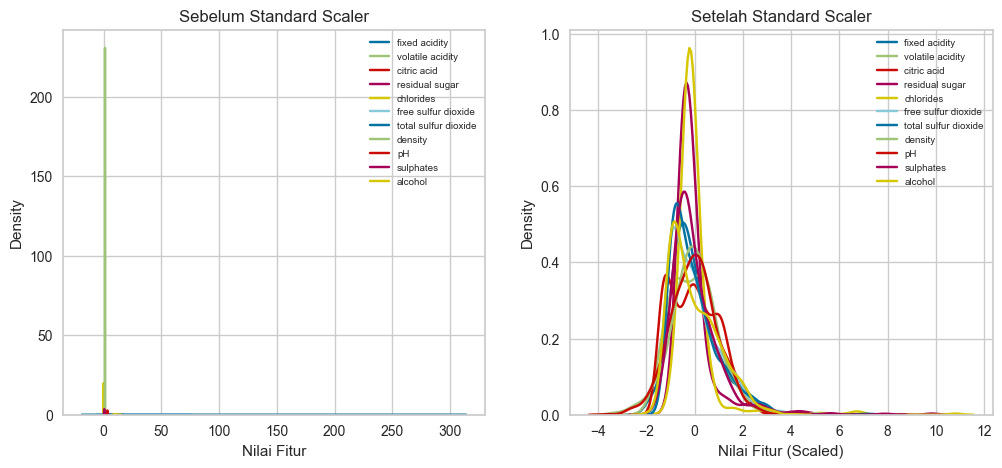

In [32]:
#cek grafik sebelum dan setelah scalling
# kita lihat distribusi dari variabel sebelum standar scaller dan setelah standar scaller

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot distribusi sebelum Standar Scaler (Isi dibawah ini)
for col in fitur_columns:
    sns.kdeplot(df[col], ax=ax1, label=col)
ax1.set_title('Sebelum Standard Scaler')

# Plot distribusi setelah Standar Scaler (Isi dibawah ini)
for col in fitur_columns:
    sns.kdeplot(df_scalling[col], ax=ax2, label=col)
ax2.set_title('Setelah Standard Scaler')

# Set x-labels
ax1.set_xlabel('Nilai Fitur')
ax2.set_xlabel('Nilai Fitur (Scaled)')

# Menampilkan legenda
ax1.legend(fontsize=7)
ax2.legend(fontsize=7)

plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Sebelum dilakukan Standard Scaler, distribusi fitur memiliki skala yang sangat berbeda-beda (misalnya total sulfur dioxide memiliki range ratusan, sedangkan density memiliki range < 1), sehingga sulit untuk dibandingkan secara langsung.
2. Setelah dilakukan Standard Scaler, semua fitur memiliki mean = 0 dan standar deviasi = 1, sehingga distribusi fitur menjadi seragam dan dapat dibandingkan secara adil dalam proses clustering.


## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label anotator.
1. Metode Elbow
2. Via-Score plot

### Metode Elbow

Text(0, 0.5, 'Intertia / WSS')

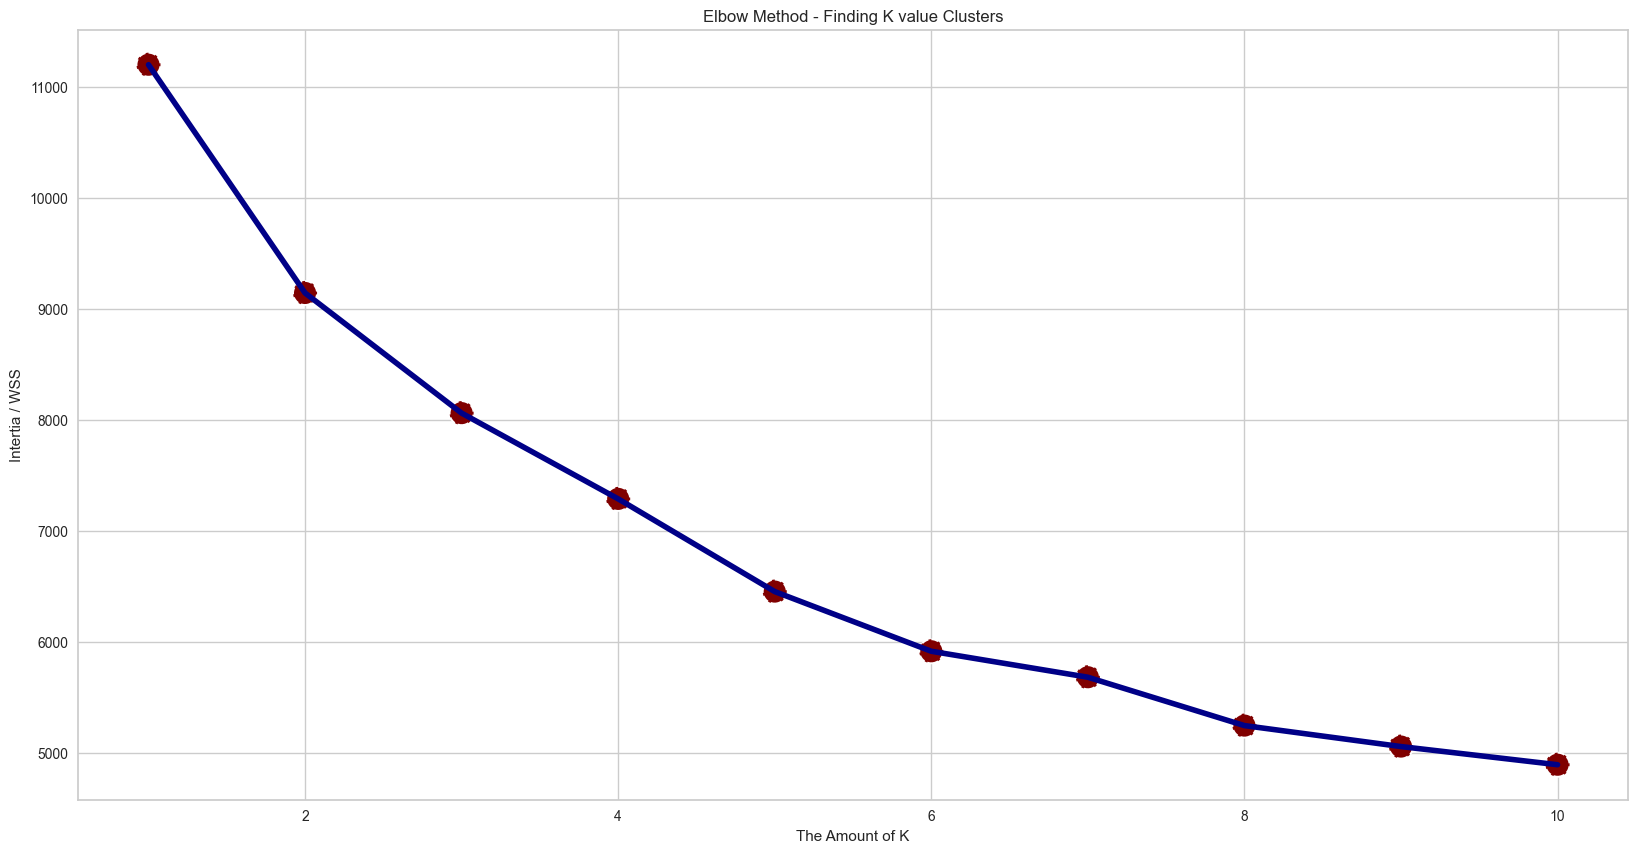

In [33]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))

sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth = 4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000',  linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Intertia / WSS')

In [34]:
#Dari hasil diatas elbow nya dipilih pada angka 3,
# karena titik awal sebelum titik selanjutnya memiliki gap yang konstan atau
# titik setelah lekukan tajam sebelum mendatar
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=3, random_state=0)
kmeans_elbow.fit(df_scalling.values)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [35]:
#taruh hasil k-means elbow method ke df dengan nama kolom cluster_elbow
df['cluster_elbow'] = kmeans_elbow.labels_

In [36]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster_elbow
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,2
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,1
4,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1013,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,2
1014,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,2
1015,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,2
1016,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,2


Text(0.5, 1.0, 'Hasil Clustering K-Means (Elbow Method) - alcohol vs volatile acidity')

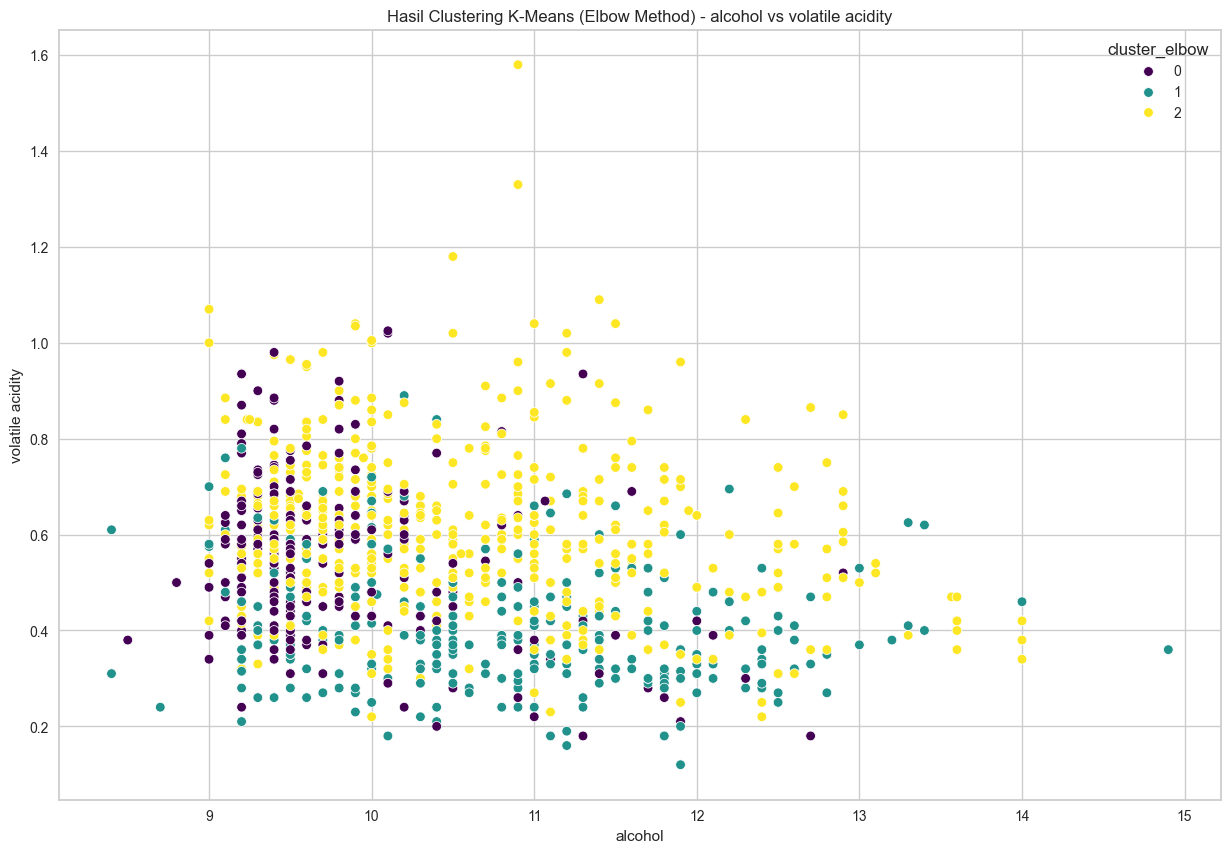

In [37]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='volatile acidity', hue='cluster_elbow', palette='viridis')
plt.title('Hasil Clustering K-Means (Elbow Method) - alcohol vs volatile acidity')

### Bandingkan hasil dengan label anotator

Text(0.5, 1.0, 'Distribusi Data Asli berdasarkan Quality - alcohol vs volatile acidity')

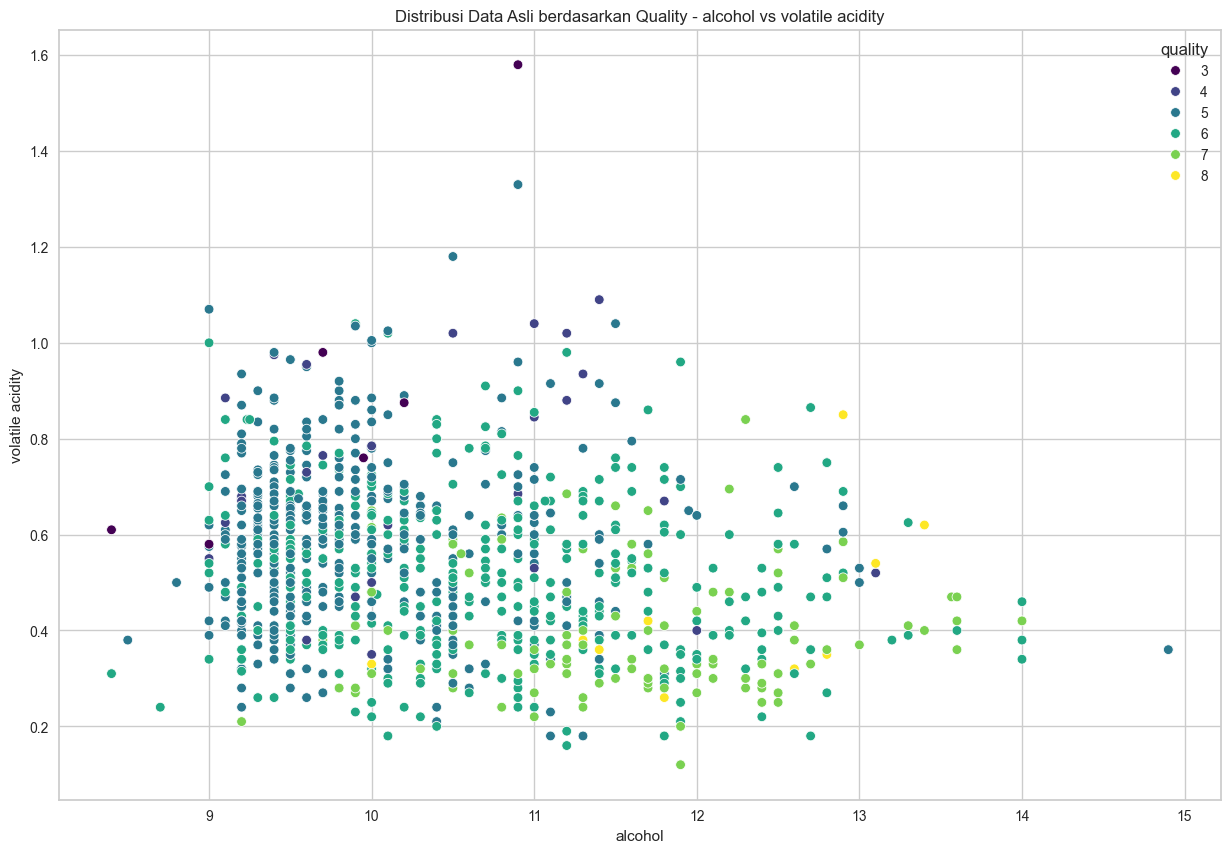

In [38]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='volatile acidity', hue='quality', palette='viridis')
plt.title('Distribusi Data Asli berdasarkan Quality - alcohol vs volatile acidity')

### Hasil diatas ketika menggunakan elbow method, cluster yang terbentuk dapat dibandingkan dengan label anotator (quality). Dengan kondisi :
1. Cluster 0 -> Wine dengan kualitas sedang
2. Cluster 1 -> Wine dengan kualitas tinggi
3. Cluster 2 -> Wine dengan kualitas rendah

### 2. Via Score Plot

In [39]:
!pip install yellowbrick

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


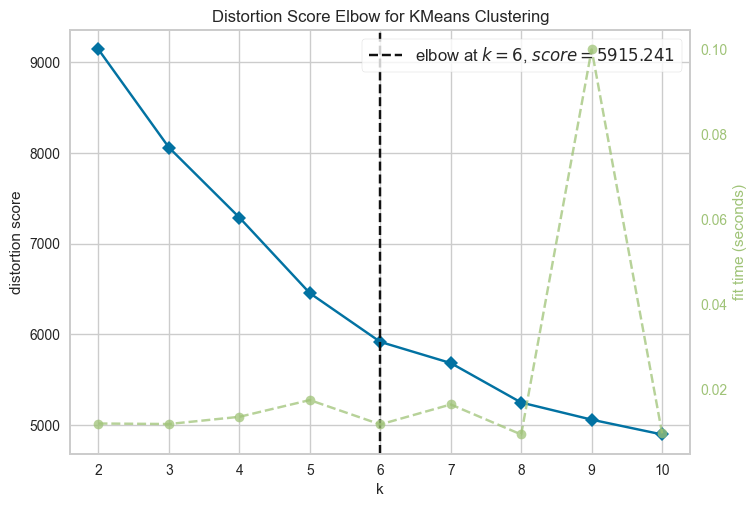

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [40]:
# Via Score Plot
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

k_means_via = KMeans(random_state=0)
# k is range of number of clusters.
visualizer = KElbowVisualizer(
    k_means_via, k=(2, 11), timings=True, force_model=True
)
visualizer.fit(df_scalling.values)        # Fit the data to the visualizer
visualizer.set_title('Distortion Via-Score Plot for K-Means Clustering')
visualizer.show()

In [41]:
# Dari hasil diatas K-nya dipilih berdasarkan rekomendasi visualizer
from sklearn.cluster import KMeans

k_optimal = visualizer.elbow_value_
print(f'Nilai K optimal berdasarkan Via Score: {k_optimal}')

# Jika visualizer tidak menemukan elbow, gunakan default k=4
if k_optimal is None:
    k_optimal = 4
    print(f'Visualizer tidak menemukan elbow secara otomatis, menggunakan K={k_optimal}')

kmeans_via = KMeans(n_clusters=k_optimal, random_state=0)
kmeans_via.fit(df_scalling.values)

Nilai K optimal berdasarkan Via Score: 6


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",6
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [42]:
#taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [43]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster_elbow,cluster_via
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,2,2
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,0,2
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,1,3
4,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1013,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,2,5
1014,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,2,2
1015,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,2,5
1016,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,2,5


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

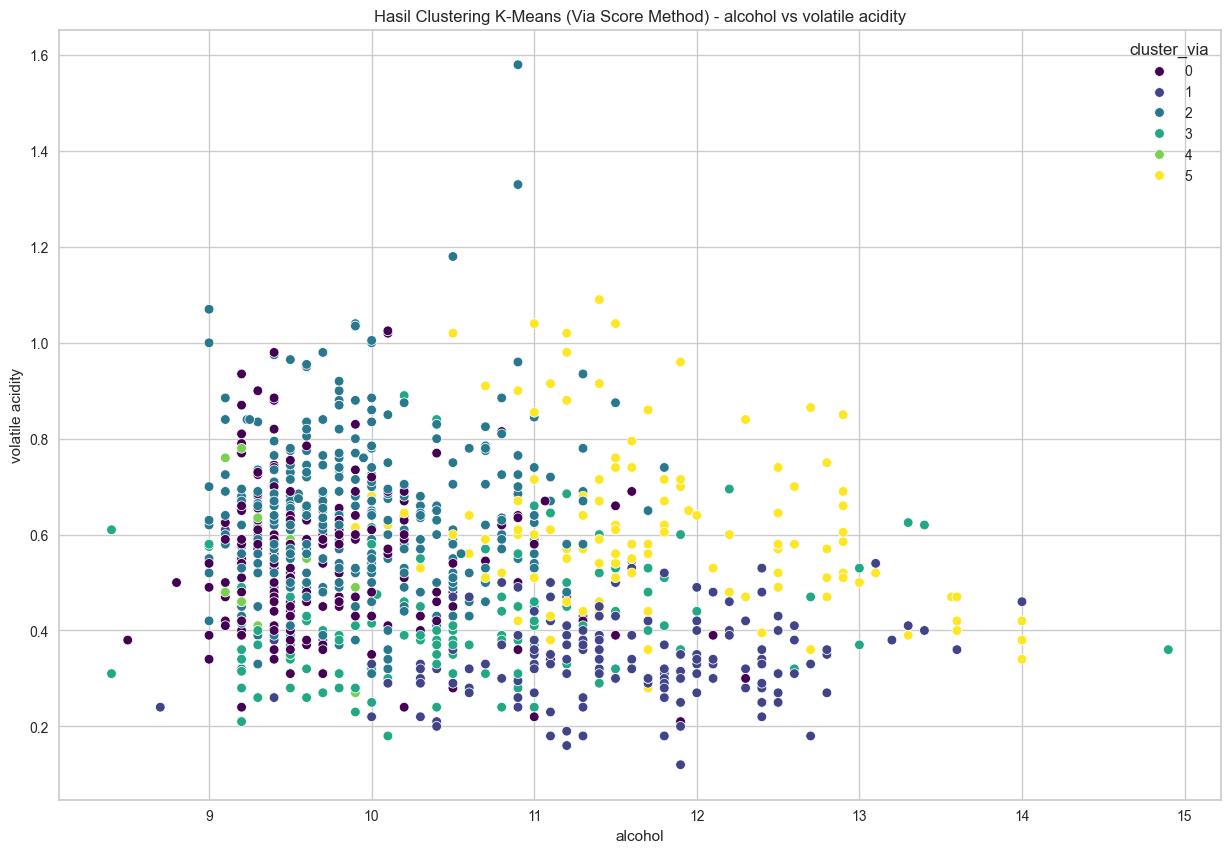

In [44]:
#Lakukan evaluasi setelah dilakukan K-Means
#Bandingkan hasil cluster dengan distribusi data asli
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='volatile acidity', hue='cluster_via', palette='viridis')
plt.title('Hasil Clustering K-Means (Via Score Method) - alcohol vs volatile acidity')
plt.show()

### Bandingkan dengan label anotator

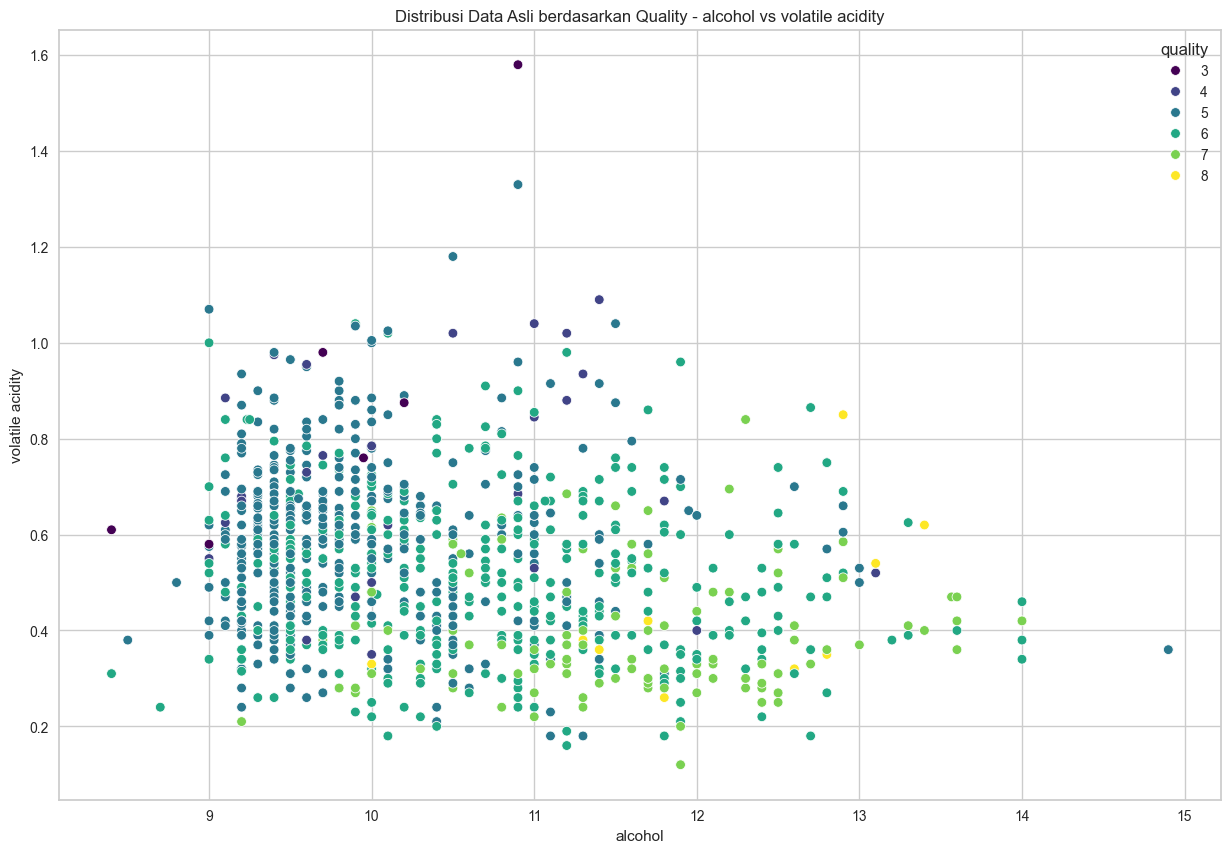

In [45]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='volatile acidity', hue='quality', palette='viridis')
plt.title('Distribusi Data Asli berdasarkan Quality - alcohol vs volatile acidity')
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Hasil clustering menggunakan Via Score Method menghasilkan cluster yang memisahkan data wine berdasarkan pola fitur kimiawi.
2. Ketika dibandingkan dengan label anotator (quality), cluster yang dihasilkan tidak sepenuhnya cocok karena quality wine memiliki 6 kategori (3-8), sedangkan jumlah cluster yang direkomendasikan oleh visualizer berbeda. Namun, pola umum pemisahan data sudah cukup baik terlihat pada plot alcohol vs volatile acidity.
3. Metode Via Score menggunakan distortion score untuk menentukan K optimal secara otomatis, sehingga lebih objektif dibandingkan Elbow Method yang bergantung pada interpretasi visual.


### Thank you :)